In [179]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score , classification_report
from sklearn.impute import SimpleImputer

In [180]:
df = pd.read_csv("Cleaned_Dataset.csv")

In [181]:
df.head()

,Transaction_ID,Customer_ID,Product_ID,Product_Name,Category,Brand,Price,Rating,Reviews_Count,Stock,...,Fraud_Flag,Customer_Query,AI_Recommendation,Year,Month,Day,Day_Name,Sales_Category,Revenue_PerUnit,Inventory_Status
0,T0001,C9958,148,Dell Product 148,Mobiles,Dell,77260,4.4,2043,92,...,0,Is this product available?,Urgent inventory alert,2025,1,17,Friday,Negative Growth,77260.0,Healthy
1,T0002,C7852,123,Dell Product 123,Home,Dell,98245,4.8,2547,96,...,0,How long is delivery?,Increase marketing,2025,1,13,Monday,High Growth,98245.0,Healthy
2,T0003,C7712,112,Apple Product 112,Mobiles,Apple,68808,4.0,3670,43,...,0,Can I replace damaged items?,Apply festive discount,2025,9,24,Wednesday,Moderate Growth,68808.0,Low
3,T0004,C6430,129,Sony Product 129,Mobiles,Sony,96501,4.9,3964,46,...,0,Which product is best?,Urgent inventory alert,2025,3,25,Tuesday,Moderate Growth,96501.0,Low
4,T0005,C8203,115,Boat Product 115,Home,Boat,73435,3.6,2445,68,...,0,How long is delivery?,Restock product,2025,2,17,Monday,Negative Growth,73435.0,Healthy


In [182]:
print(df.columns)

Index(['Transaction_ID', 'Customer_ID', 'Product_ID', 'Product_Name',
       'Category', 'Brand', 'Price', 'Rating', 'Reviews_Count', 'Stock',
       'Discount_Percentage', 'Region', 'Store_ID', 'Date', 'Holiday_Flag',
       'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Previous_Sales',
       'Current_Sales', 'Sales_Growth_Percentage', 'Demand_Level',
       'Inventory_Risk', 'Transaction_Quantity', 'Total_Amount',
       'Payment_Method', 'Fraud_Flag', 'Customer_Query', 'AI_Recommendation',
       'Year', 'Month', 'Day', 'Day_Name', 'Sales_Category', 'Revenue_PerUnit',
       'Inventory_Status'],
      dtype='object')


In [183]:
features = [
    "Price", "Rating", "Reviews_Count", "Stock",
    "Discount_Percentage", "Holiday_Flag", "Temperature", "Fuel_Price",
    "CPI", "Unemployment", "Previous_Sales", "Transaction_Quantity", "Fraud_Flag", "Month"
]

target = "Current_Sales"

In [184]:
categorical_columns = [
    "Category",
    "Brand",
    "Region",
    "Demand_Level",
    "Inventory_Risk",
    "Payment_Method"
]

In [185]:
# Features and Target
X = df.drop("Current_Sales", axis=1)
y = df["Current_Sales"]

# Automatically detect categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

# Automatically detect numerical columns
numerical_columns = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: ['Transaction_ID', 'Customer_ID', 'Product_Name', 'Category', 'Brand', 'Region', 'Date', 'Demand_Level', 'Inventory_Risk', 'Payment_Method', 'Customer_Query', 'AI_Recommendation', 'Day_Name', 'Sales_Category', 'Inventory_Status']
Numerical Columns: ['Product_ID', 'Price', 'Rating', 'Reviews_Count', 'Stock', 'Discount_Percentage', 'Store_ID', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Previous_Sales', 'Sales_Growth_Percentage', 'Transaction_Quantity', 'Total_Amount', 'Fraud_Flag', 'Year', 'Month', 'Day', 'Revenue_PerUnit']


In [186]:

x_train , x_temp , y_train , y_temp = train_test_split(
    X,y,test_size = 0.1 , random_state = 42
)

x_test , x_val , y_test , y_val = train_test_split(
    x_temp , y_temp , test_size = 0.1 , random_state = 42
)


print(f"Training Set :  {len(x_train)}")
print(f"Validation Set :  {len(x_val)}")
print(f"Test Set :  {len(x_test)}")

print("Training Shape:", x_train.shape)
print("Testing Shape:", y_test.shape)

Training Set :  450
Validation Set :  5
Test Set :  45
Training Shape: (450, 36)
Testing Shape: (45,)


In [187]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [188]:
numeric_transformer

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [189]:
categorical_transformer

,steps,"[('imputer', ...), ('onehot', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [190]:

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, features),
    ("cat", categorical_transformer, categorical_columns)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [191]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [192]:
pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [196]:
predictions = pipeline.predict(x_test)

In [169]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

In [170]:
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.2f}")

MAE  : 20.57
MSE  : 699.98
RMSE : 26.46
R2 Score : 0.96


In [171]:
# Get transformed feature names
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get coefficients
coefficients = pipeline.named_steps[
    "model"
].coef_

# Create dataframe
feature_impact = pd.DataFrame({
    "Feature_Name": feature_names,
    "Impact_on_Prediction": coefficients
})

# Sort
feature_impact = feature_impact.sort_values(
    by="Impact_on_Prediction",
    ascending=False
)

print(feature_impact)

                             Feature_Name  Impact_on_Prediction
10                    num__Previous_Sales            107.917684
1439      cat__Sales_Category_High Growth             57.785031
1412               cat__Demand_Level_High             38.872543
1339                 cat__Date_2025-09-17             23.949488
160             cat__Transaction_ID_T0166             18.203517
...                                   ...                   ...
961    cat__Product_Name_Boat Product 128            -17.107956
35              cat__Transaction_ID_T0027            -22.105246
522                cat__Customer_ID_C2064            -22.105246
1413                cat__Demand_Level_Low            -40.248506
1441  cat__Sales_Category_Negative Growth            -47.770109

[1445 rows x 2 columns]


In [172]:
model_file_name = "sales_prediction_model.pkl"
joblib.dump(pipeline, model_file_name)

print("Trained model has been saved successfully.")

Trained model has been saved successfully.


In [173]:
single_sample = x_test.iloc[0:1]
predicted_value = pipeline.predict(single_sample)

print("\nModel Prediction Check")
print("Predicted Sales:", predicted_value[0])
print("Actual Sales:", y_test.iloc[0])


Model Prediction Check
Predicted Sales: 309.1136229445819
Actual Sales: 320


In [174]:
# Visualization of my Model

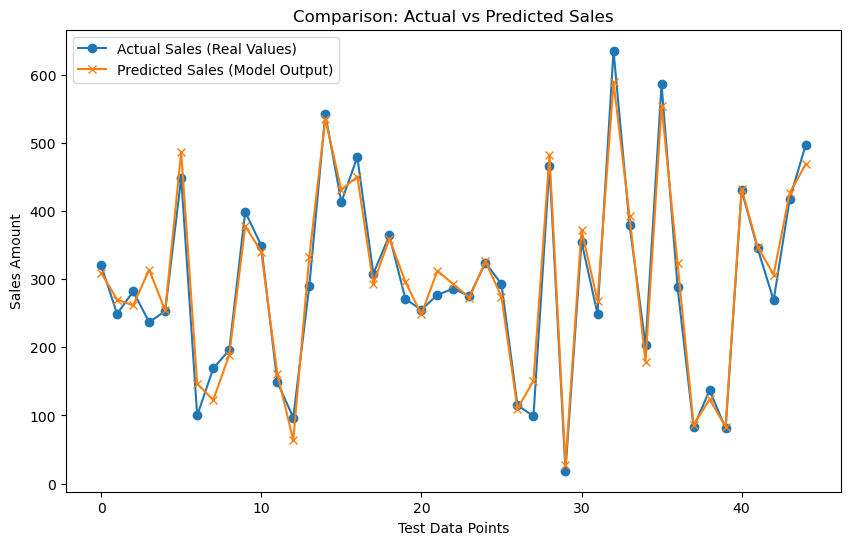

In [175]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(
    y_test.values[:50],
    label="Actual Sales (Real Values)",
    marker='o'
)

plt.plot(
    predictions[:50],
    label="Predicted Sales (Model Output)",
    marker='x'
)


plt.title("Comparison: Actual vs Predicted Sales")
plt.xlabel("Test Data Points")
plt.ylabel("Sales Amount")
plt.legend()
plt.show()

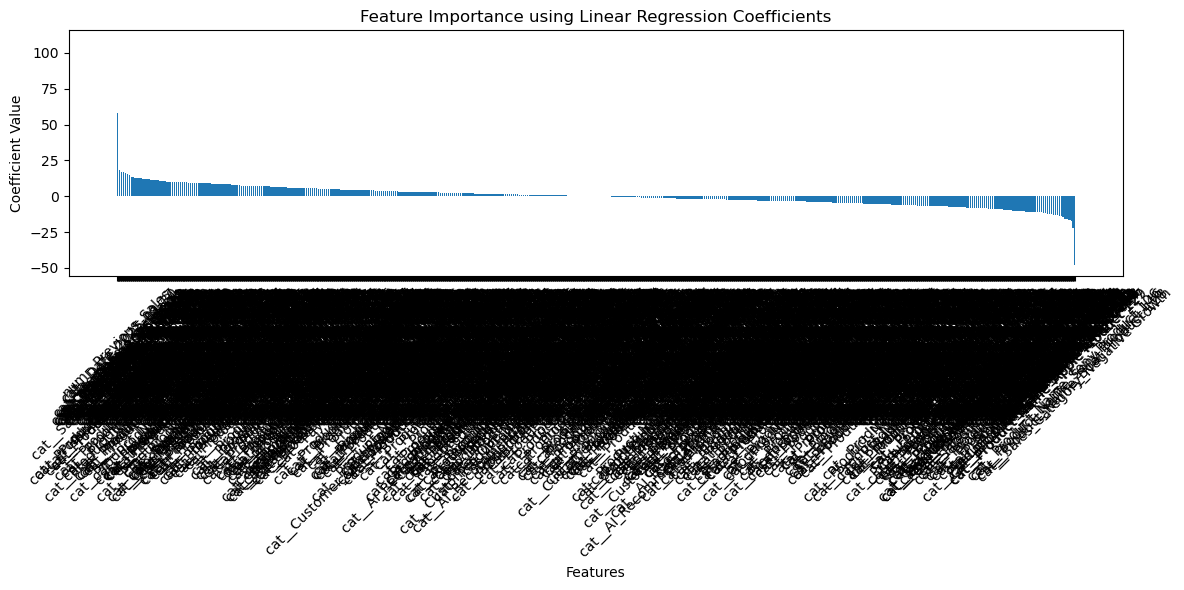

In [176]:
plt.figure(figsize=(12, 6))
plt.bar(
    feature_impact["Feature_Name"],
    feature_impact["Impact_on_Prediction"]
)


plt.xticks(rotation=45)
plt.title("Feature Importance using Linear Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()

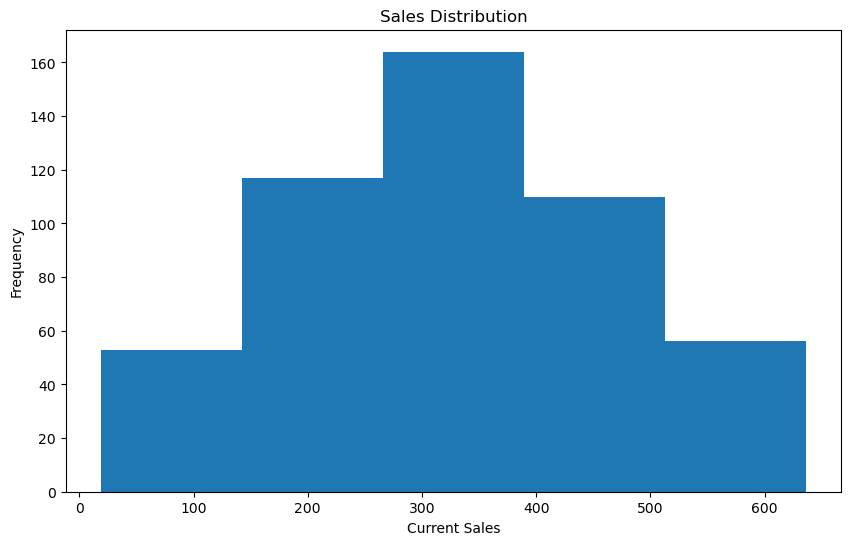

In [177]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Current_Sales"],
    bins=5
)

plt.title("Sales Distribution")
plt.xlabel("Current Sales")
plt.ylabel("Frequency")
plt.show()